In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts

from sparcl.client import SparclClient
from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"

In [2]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")


client = SparclClient()

idxs = [int(x) for x in hamann_erq["targetid"].head(10) if x != "Not found"]

output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

spectra_df = pd.DataFrame(spectra.data[1:])

spectra_df

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


,targetid,redshift,spectype,redshift_warning,specid,flux,ivar,wavelength,_dr
0,39628078766358575,2.199301,QSO,0,39628078766358575,"[6.083261489868164, 7.300170421600342, 5.58030...","[0.09443012624979019, 0.11103168874979019, 0.1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,39627730584601174,1.782655,QSO,0,39627730584601174,"[0.4372713565826416, 2.111987352371216, -4.080...","[0.07881371676921844, 0.0627162829041481, 0.06...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,39628365275075274,2.837482,QSO,0,39628365275075274,"[0.7628244161605835, -1.0635453462600708, 0.83...","[0.33674854040145874, 0.3539333641529083, 0.37...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
3,39628504643403849,2.360326,QSO,0,39628504643403849,"[0.29033735394477844, 3.1691737174987793, -2.4...","[0.05054178088903427, 0.09497752040624619, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
4,39627706643513715,2.536830,QSO,0,39627706643513715,"[3.230962038040161, -2.0705037117004395, 2.608...","[0.17553436756134033, 0.1668706238269806, 0.18...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
5,39628078770555722,2.430429,QSO,0,39628078770555722,"[1.2459850311279297, -3.726759195327759, -1.50...","[0.0447843037545681, 0.056199029088020325, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
6,39627640176382892,2.452858,QSO,0,39627640176382892,"[2.040266513824463, 2.7940256595611572, -1.077...","[0.13237154483795166, 0.1565820425748825, 0.15...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


In [3]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import f as f_dist
from lmfit import Model, Parameters
import warnings

In [4]:
C_KMS        = 2.99792458e5   # speed of light (km/s)
CIV_VACUUM   = 1549.48        # CIV rest wavelength (Angstrom), doublet ignored
FIT_WINDOW   = (1450, 1650)   # fitting window (rest-frame Angstrom)
 
# Two-Gaussian constraints
MIN_WIDTH_RATIO = 1.2         # wing sigma >= this * core sigma
MAX_WIDTH_RATIO = 4.0         # wing sigma <= this * core sigma
MIN_CORE_SIGMA  = 3.0         # Angstrom
MAX_CORE_SIGMA  = 80.0        # Angstrom (~15000 km/s FWHM)
MAX_WING_SIGMA  = 200.0       # Angstrom
 
# F-test significance threshold
FTEST_PVALUE    = 0.05
 
# BAL masking thresholds
BAL_SIGMA_MASK  = 2.5
BAL_MIN_WIDTH   = 10          # Angstrom
 
# kt80 percentiles
PCT_INNER = 20
PCT_OUTER = 80

In [5]:
def wave_to_vel(wave, wave0=CIV_VACUUM):
    return C_KMS * (wave - wave0) / wave0
 
 
def _gaussian(x, amplitude, center, sigma):
    return amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)

In [6]:
def make_bal_mask(wave, flux_sub, ivar=None,
                  sigma_thresh=BAL_SIGMA_MASK,
                  min_width_aa=BAL_MIN_WIDTH,
                  window=FIT_WINDOW):
    win      = (wave >= window[0]) & (wave <= window[1])
    bal_mask = np.zeros(len(wave), dtype=bool)
 
    if ivar is not None and np.any(ivar[win] > 0):
        noise = np.where(ivar > 0, 1.0 / np.sqrt(np.maximum(ivar, 1e-30)), np.inf)
    else:
        noise_est = np.percentile(np.abs(flux_sub[win]), 10)
        noise     = np.full(len(wave), max(noise_est, 1e-30))
 
    below   = flux_sub < -sigma_thresh * noise
    in_run  = False
    run_start = 0
 
    for i in range(len(wave)):
        if below[i] and not in_run:
            in_run    = True
            run_start = i
        elif not below[i] and in_run:
            in_run = False
            if wave[i - 1] - wave[run_start] >= min_width_aa:
                bal_mask[run_start:i] = True
    if in_run and wave[-1] - wave[run_start] >= min_width_aa:
        bal_mask[run_start:] = True
 
    return bal_mask

In [7]:
def fit_single_gaussian(wave, flux_sub, ivar=None, mask=None,
                         window=FIT_WINDOW):
    win = (wave >= window[0]) & (wave <= window[1])
    if mask is not None:
        win &= ~mask
    if win.sum() < 5:
        raise ValueError("Too few unmasked pixels in CIV window.")
 
    xd      = wave[win]
    yd      = flux_sub[win]
    weights = np.sqrt(ivar[win]) if ivar is not None else np.ones(win.sum())
    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 1.0)
 
    gmodel = Model(_gaussian)
    params = gmodel.make_params(
        amplitude=dict(value=max(yd.max(), 1e-30), min=0),
        center   =dict(value=xd[np.argmax(yd)], min=window[0], max=window[1]),
        sigma    =dict(value=20.0, min=MIN_CORE_SIGMA, max=MAX_CORE_SIGMA),
    )
    result  = gmodel.fit(yd, params, x=xd, weights=weights, method='least_squares')
    profile = _gaussian(wave, result.best_values['amplitude'],
                        result.best_values['center'],
                        result.best_values['sigma'])
    return result, profile

In [8]:
def _two_gaussian(x, amp_c, cen_c, sigma_c, amp_w, cen_w, sigma_w):
    core = amp_c * np.exp(-0.5 * ((x - cen_c) / sigma_c) ** 2)
    wing = amp_w * np.exp(-0.5 * ((x - cen_w) / sigma_w) ** 2)
    return core + wing
 
 
def fit_two_gaussians(wave, flux_sub, ivar=None, mask=None,
                      single_result=None, window=FIT_WINDOW):
    win = (wave >= window[0]) & (wave <= window[1])
    if mask is not None:
        win &= ~mask
    if win.sum() < 8:
        raise ValueError("Too few pixels for two-Gaussian fit.")
 
    xd      = wave[win]
    yd      = flux_sub[win]
    weights = np.sqrt(ivar[win]) if ivar is not None else np.ones(win.sum())
    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 1.0)
 
    if single_result is not None:
        bv   = single_result.best_values
        amp0 = bv['amplitude']
        cen0 = bv['center']
        sig0 = bv['sigma']
    else:
        amp0 = max(yd.max(), 1e-30)
        cen0 = CIV_VACUUM
        sig0 = 20.0
 
    sig_w0 = np.clip(sig0 * 2.0, sig0 * MIN_WIDTH_RATIO, MAX_WING_SIGMA)
    hw     = 1.1775 * sig_w0   # half-FWHM of wing for core centroid bound
 
    tmodel = Model(_two_gaussian)
    params = Parameters()
 
    # Wing
    params.add('amp_w',      value=amp0 * 0.5, min=0)
    params.add('cen_w',      value=cen0, min=window[0], max=window[1])
    params.add('sigma_c',    value=sig0,  min=MIN_CORE_SIGMA, max=MAX_CORE_SIGMA)
    params.add('width_ratio',value=2.0,   min=MIN_WIDTH_RATIO, max=MAX_WIDTH_RATIO)
    params.add('sigma_w',    expr='width_ratio * sigma_c')
 
    # Core
    params.add('amp_c',      value=amp0 * 0.7, min=0)
    params.add('delta_cen',  value=0.0, min=-hw, max=hw)
    params.add('cen_c',      expr='cen_w + delta_cen')
 
    result  = tmodel.fit(yd, params, x=xd, weights=weights, method='least_squares')
    bv      = result.best_values
    profile = _two_gaussian(wave,
                             bv['amp_c'], bv['cen_c'], bv['sigma_c'],
                             bv['amp_w'], bv['cen_w'], bv['sigma_w'])
    return result, profile

In [9]:
def ftest_two_vs_one(result1, result2, alpha=FTEST_PVALUE):
    rss1 = result1.residual @ result1.residual
    rss2 = result2.residual @ result2.residual
    n    = len(result1.residual)
    p1   = result1.nvarys
    p2   = result2.nvarys
 
    if rss2 <= 0 or rss1 <= rss2:
        return False, 1.0
 
    f_stat = ((rss1 - rss2) / (p2 - p1)) / (rss2 / (n - p2))
    p_val  = 1.0 - f_dist.cdf(f_stat, dfn=(p2 - p1), dfd=(n - p2))
    return p_val < alpha, p_val

In [10]:
def _profile_width(wave, profile, level):
    above     = profile >= level
    crossings = np.where(np.diff(above.astype(int)))[0]
    if len(crossings) < 2:
        return np.nan
    i         = crossings[0]
    lam_left  = np.interp(level, [profile[i], profile[i+1]], [wave[i], wave[i+1]])
    j         = crossings[-1]
    lam_right = np.interp(level, [profile[j+1], profile[j]], [wave[j+1], wave[j]])
    return lam_right - lam_left
 
 
def _kurtosis_index(wave, profile, pct_inner=PCT_INNER, pct_outer=PCT_OUTER):
    """
    kt80 = Dv(80%) / Dv(20%)
    Dv(X%) = velocity width enclosing the central X% of total line flux,
    measured symmetrically about the CDF median.
    """
    vel     = wave_to_vel(wave)
    sort_idx = np.argsort(vel)
    v_s     = vel[sort_idx]
    p_s     = np.maximum(profile[sort_idx], 0)
    total   = np.trapz(p_s, v_s)
    if total <= 0:
        return np.nan
 
    cum = np.zeros(len(v_s))
    for i in range(1, len(v_s)):
        cum[i] = cum[i-1] + 0.5 * (p_s[i] + p_s[i-1]) * (v_s[i] - v_s[i-1])
    cum /= total
 
    def vel_at_cdf(q):
        if q <= cum[0]:  return float(v_s[0])
        if q >= cum[-1]: return float(v_s[-1])
        return float(np.interp(q, cum, v_s))
 
    dv_inner = vel_at_cdf(0.5 + pct_inner/200) - vel_at_cdf(0.5 - pct_inner/200)
    dv_outer = vel_at_cdf(0.5 + pct_outer/200) - vel_at_cdf(0.5 - pct_outer/200)
    return np.nan if dv_inner <= 0 else dv_outer / dv_inner
 
 
def measure_line(wave, profile, flux_sub, continuum_flux, window=FIT_WINDOW):
    win = (wave >= window[0]) & (wave <= window[1]) & (profile > 0)
    if win.sum() < 5:
        return {k: np.nan for k in
                ['fwhm_kms','ew_aa','line_flux','centroid_kms','kt80']}
 
    w  = wave[win]
    p  = profile[win]
    fs = flux_sub[win]
    fc = continuum_flux[win] if continuum_flux is not None else np.ones(win.sum())
 
    fwhm_aa      = _profile_width(w, p, 0.5 * p.max())
    fwhm_kms     = C_KMS * fwhm_aa / CIV_VACUUM
    centroid_aa  = np.trapz(w * p, w) / np.trapz(p, w)
    centroid_kms = wave_to_vel(centroid_aa)
 
    line_win  = win & (profile > 0.01 * profile[win].max())
    line_flux = np.trapz(flux_sub[line_win], wave[line_win])
 
    with np.errstate(divide='ignore', invalid='ignore'):
        ew_integrand = np.where(fc > 0, fs / fc, 0.0)
    ew_aa = np.trapz(ew_integrand, w)
 
    kt80 = _kurtosis_index(w, p)
 
    return dict(fwhm_kms=fwhm_kms, ew_aa=ew_aa, line_flux=line_flux,
                centroid_kms=centroid_kms, kt80=kt80)

In [39]:
idx = 2

lam = np.array(spectra_df["wavelength"][idx])
flux = np.array(spectra_df["flux"][idx])
ivar = np.array(spectra_df["ivar"][idx])
z = spectra_df["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar)

result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)

flux_sub = flux_clean - continuum if not rejected else None

{'fwhm_kms': 3487.548926713952, 'ew_aa': 148.06124161517286, 'line_flux': 221.78476560043782, 'centroid_kms': -4597.276318264688, 'kt80': 4.847610548901393}


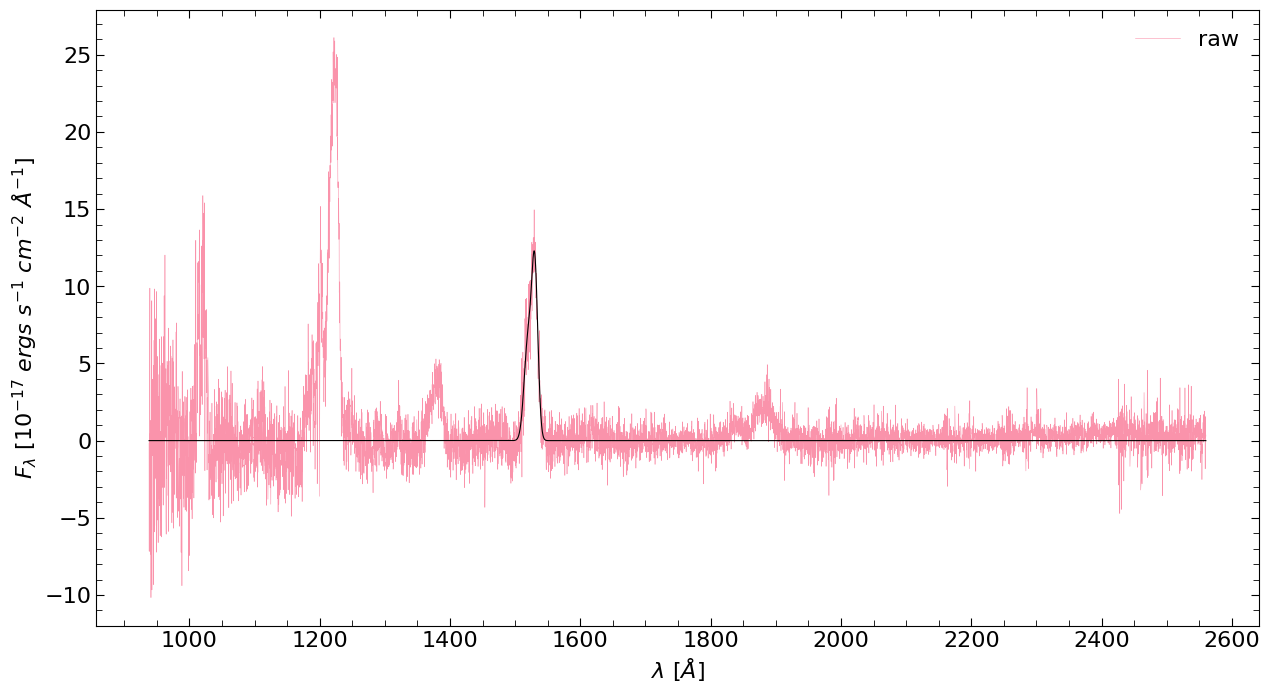

In [ ]:
bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar)

result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

accept_two, p_val = ftest_two_vs_one(result1, result2)

if accept_two:
    line_stats = measure_line(lam, profile2, flux_sub, continuum)
    print(line_stats)
    plot_spectrum(lam, flux_sub, add_smoothed=False, additional_flux=profile2)
else:
    line_stats = measure_line(lam, profile1, flux_sub, continuum)
    print(line_stats)
    plot_spectrum(lam, flux_sub, add_smoothed=False, additional_flux=profile1)

In [48]:
hamann_erq[hamann_erq["targetid"]==str(spectra_df["targetid"][idx])][['sdss_name','f1450','rew','fwhm','kt80']]


,sdss_name,f1450,rew,fwhm,kt80
2,002400.25+245031.9,0.394071,143.689957,3523.281699,0.372201
